## Clean version of our assignment

Importing packages 

In [ ]:
import pandas as pd
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn import datasets as ds
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import decomposition

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import sklearn.metrics as sklm
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
from scipy.stats import ttest_ind

Load data 

In [ ]:
with zipfile.ZipFile("ecg_data.zip","r") as zip_ref:
    zip_ref.extractall("ecg_data")

def load_data():
    this_directory = os.getcwd()
    data = pd.read_csv(os.path.join(this_directory, 'ecg_data/ecg_data.csv'), index_col=0)
    return data

raw_data = load_data()

Data description

In [ ]:
print(f'The number of samples: {len(raw_data.index)}')
print(f'The number of columns: {len(raw_data.columns)}')

print(f'The number of NaN values in the entire dataframe: {raw_data.isnull().sum().sum()}')
print(f'The number of samples with label 0: {len(raw_data[raw_data["label"] == 0])}')
print(f'The number of samples with label 1: {len(raw_data[raw_data["label"] == 1])}')
print(f'The percentage of samples with label 0 is thus {len(raw_data[raw_data["label"] == 0])/len(raw_data.index)*100:.2f}%', 
      f'and the percentage with label 1 {len(raw_data[raw_data["label"] == 1])/len(raw_data.index)*100:.2f}%')

# print(raw_data.groupby('label').count())
# print(raw_data.groupby('label').mean())
# print(raw_data.groupby('label').var())
# print(raw_data.groupby('label').std())


The number of samples: 827
The number of columns: 9001
The number of NaN values in the entire dataframe: 0
The number of samples with label 0: 681
The number of samples with label 1: 146
The percentage of samples with label 0 is thus 82.35% and the percentage with label 1 17.65%


Splitting the data in training and test sets

In [ ]:
X = raw_data.drop('label', axis=1)
Y = raw_data['label']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=4, stratify=Y)

Preprocessing

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression


class VarianceFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.columns_to_drop_ = [col for col in X.columns if np.var(X[col]) < self.threshold]
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.columns_to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


class TTestFilter(BaseEstimator, TransformerMixin):
    def __init__(self, alpha=0.05):
        self.alpha = alpha

    def fit(self, X, y):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]

        self.columns_to_drop_ = []
        threshold = self.alpha / X.shape[1]  # Bonferroni

        for col in X.columns:
            group0 = X.loc[y == 0, col]
            group1 = X.loc[y == 1, col]
            _, p_value = ttest_ind(group0, group1, nan_policy="omit")

            if p_value > threshold:
                self.columns_to_drop_.append(col)

        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


pipeline = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler())
    ])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
y_proba = pipeline.predict_proba(x_test)

#Amount of features after preprocessing 
x_train_var = pipeline.named_steps["variance"].transform(x_train)
x_train_corr = pipeline.named_steps["correlation"].transform(x_train_var)
x_train_t = pipeline.named_steps["ttest"].transform(x_train_corr)

print(f"Start amount features: {x_train.shape[1]}")
print(f"After the variance filter: {x_train_var.shape[1]}")
print(f"After the correlation filter: {x_train_corr.shape[1]}")
print(f"After the t-test filter: {x_train_t.shape[1]}")

c:\Users\yalci\miniforge3\envs\TM10011\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Start aantal features: 9000
Na variance filter: 9000
Na correlation filter: 4068
Na t-test filter: 47


Random Forest uitvoeren

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score
)


#y_train en y_test series van maken 
if isinstance(y_train, pd.DataFrame):
    if y_train.shape[1] == 1:
        y_train = y_train.iloc[:, 0]
    else:
        raise ValueError("y_train moet 1 kolom bevatten.")

if isinstance(y_test, pd.DataFrame):
    if y_test.shape[1] == 1:
        y_test = y_test.iloc[:, 0]
    else:
        raise ValueError("y_test moet 1 kolom bevatten.")
    
#splitten van oorspongelijke data in training en validatie set
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

#Random Forest model initialiseren
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

#Hyperparameters om te tunen
param_dist = {
    "n_estimators": randint(100, 600),
    "max_depth": [None, 5, 10, 20, 30, 50],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#RandomizedSearchCV uitvoeren
#scoring = average_precision = PR-AUC
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=kf,
    verbose=0,
    n_jobs=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train_sub, y_train_sub)

print("Beste parameters:")
print(random_search.best_params_)
print(f"\nBeste cross-validated PR-AUC: {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_

y_val_prob = best_rf.predict_proba(X_val)[:, 1]

val_pr_auc = average_precision_score(y_val, y_val_prob)
print(f"PR-AUC op validation set: {val_pr_auc:.4f}")

precision_val, recall_val, thresholds_val = precision_recall_curve(y_val, y_val_prob)

f1_scores_val = 2 * (precision_val[:-1] * recall_val[:-1]) / (
    precision_val[:-1] + recall_val[:-1] + 1e-8
)

best_idx = np.argmax(f1_scores_val)
best_threshold = thresholds_val[best_idx]

print(f"Beste threshold op validation set (o.b.v. F1): {best_threshold:.4f}")

#Evalueer één keer op testset met vaste threshold
y_test_prob = best_rf.predict_proba(x_test_scaled)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

test_pr_auc = average_precision_score(y_test, y_test_prob)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("\nResultaten op testset met threshold gekozen op validation set:")
print(f"PR-AUC:    {test_pr_auc:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_test_pred, zero_division=0))

#Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix - RF (threshold = {best_threshold:.2f})")
plt.show()

Voting op de Random Forest 

Accuracy: 0.8012048192771084
Precision: 0.3888888888888889
Recall: 0.2413793103448276
F1-score: 0.2978723404255319
PR-AUC: 0.385087547138119
ROC-AUC: 0.6876415806695193

Classification report:

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       137
           1       0.39      0.24      0.30        29

    accuracy                           0.80       166
   macro avg       0.62      0.58      0.59       166
weighted avg       0.77      0.80      0.78       166

Confusion Matrix:
 [[126  11]
 [ 22   7]]


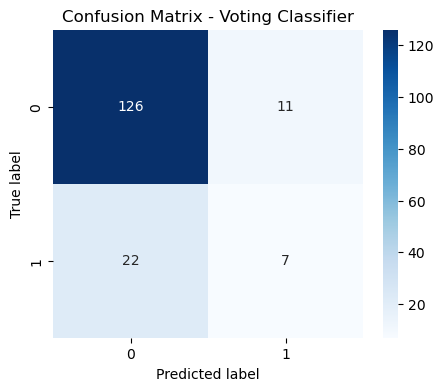

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('dt', dt)
    ],
    voting='soft'
)

voting.fit(x_train_scaled, y_train)

y_pred_vote = voting.predict(x_test_scaled)
y_prob_vote = voting.predict_proba(x_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Precision:", precision_score(y_test, y_pred_vote, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_vote, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_vote, zero_division=0))
print("PR-AUC:", average_precision_score(y_test, y_prob_vote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_vote))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_vote, zero_division=0))

cm_vote = confusion_matrix(y_test, y_pred_vote)
print("Confusion Matrix:\n", cm_vote)

plt.figure(figsize=(5,4))
sns.heatmap(cm_vote, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Voting Classifier")
plt.show()